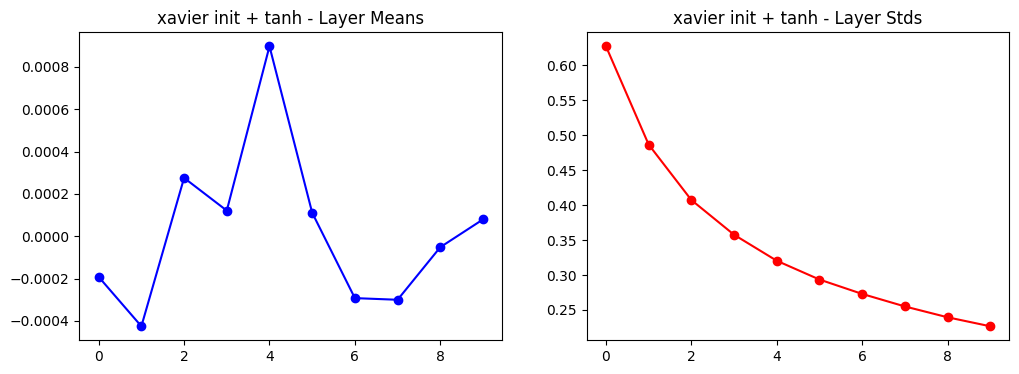

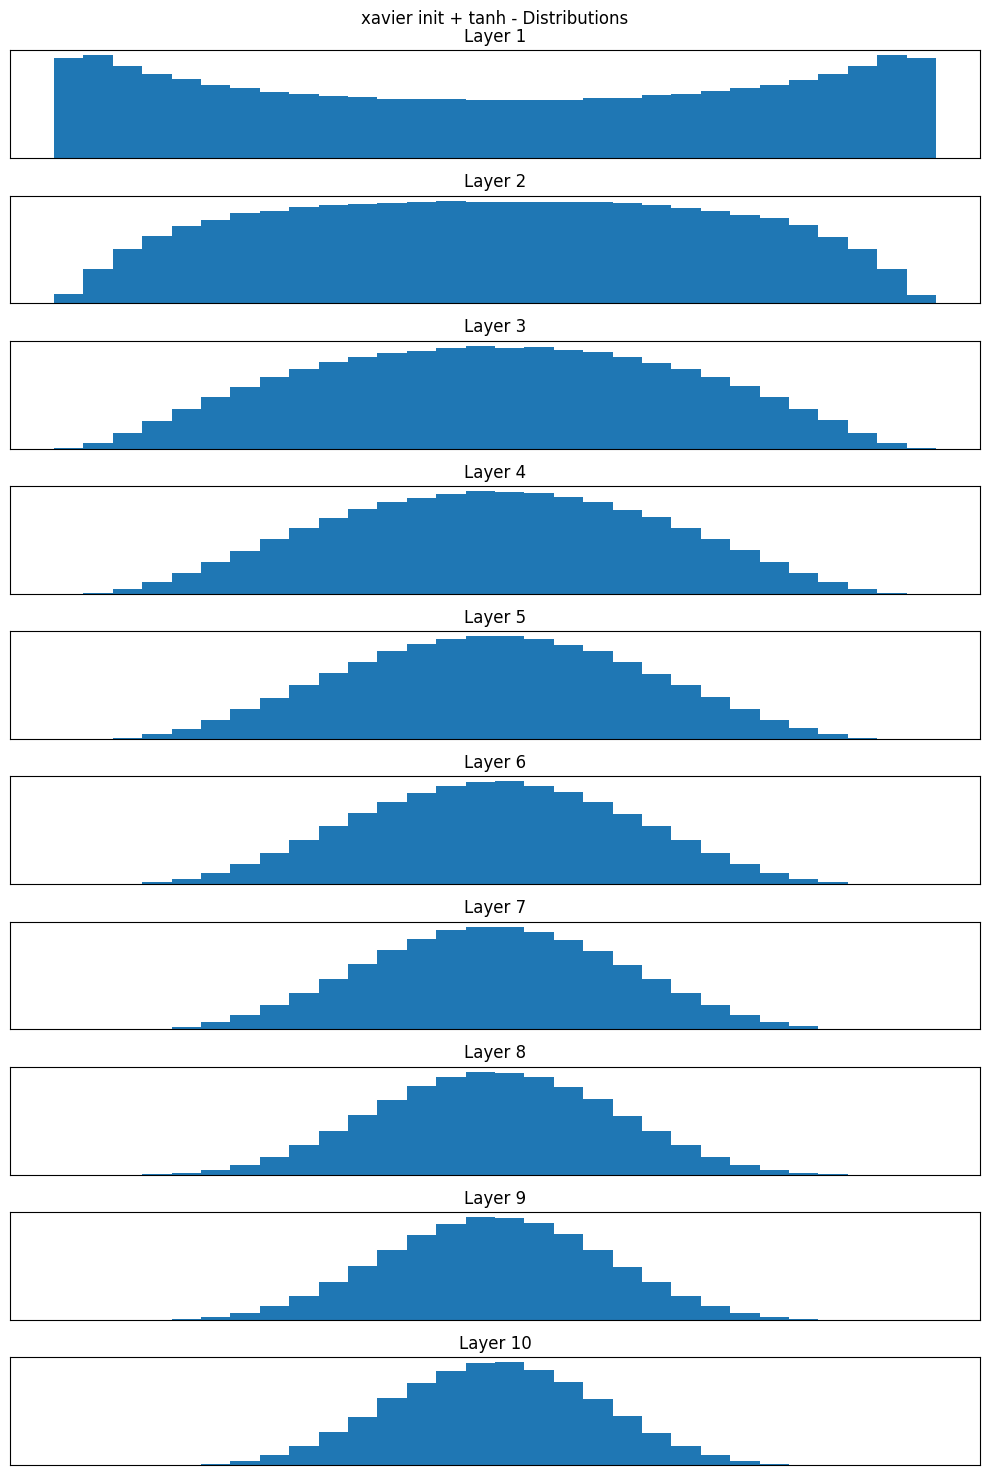

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
D = 500  # input dimension
N = 1000 # number of samples
hidden_layer_sizes = [500] * 10  # 10 layers, each with 500 neurons
nonlinearities = ['tanh']  # activation function

# Activation functions
act_funcs = {
    'relu': lambda x: np.maximum(0, x),  # ReLU activation function
    'tanh': lambda x: np.tanh(x)  # Tanh activation function
}

# Weight initialization methods
init_methods = {
    'xavier': lambda fan_in, fan_out: np.random.randn(fan_in, fan_out) / np.sqrt(fan_in),  # Xavier initialization
}

# Experiment function to run and plot the results
def run_and_plot(activation, init_type):
    np.random.seed(0)  # Set seed for reproducibility
    X = np.random.randn(N, D)  # Generate input data (N samples, D features)
    Hs = {}  # Dictionary to store activations for each layer
    nonlin = act_funcs[activation]  # Select activation function based on the argument
    init_fn = init_methods[init_type]  # Select weight initialization method

    # Forward pass through each layer
    for i in range(len(hidden_layer_sizes)):
        X = X if i == 0 else Hs[i-1]  # For the first layer, use the input data; for others, use the previous layer's output
        fan_in = X.shape[1]  # Number of input features (size of previous layer)
        fan_out = hidden_layer_sizes[i]  # Number of neurons in the current layer
        W = init_fn(fan_in, fan_out)  # Initialize weights using the selected method
        H = X @ W  # Compute activations for the current layer (Matrix multiplication)
        H = nonlin(H)  # Apply the activation function
        Hs[i] = H  # Store the activations for this layer

    # Calculate the mean and standard deviation of the activations for each layer
    layer_means = [np.mean(H) for H in Hs.values()]  # Mean of activations per layer
    layer_stds = [np.std(H) for H in Hs.values()]  # Standard deviation of activations per layer

    # Plot the mean and standard deviation of activations
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(Hs.keys(), layer_means, 'ob-')  # Plot layer means
    plt.title(f'{init_type} init + {activation} - Layer Means')

    plt.subplot(1, 2, 2)
    plt.plot(Hs.keys(), layer_stds, 'or-')  # Plot layer standard deviations
    plt.title(f'{init_type} init + {activation} - Layer Stds')
    plt.show()

    # Plot histograms of activations for each layer
    plt.figure(figsize=(10, 15))
    for i, H in Hs.items():
        plt.subplot(len(Hs), 1, i + 1)
        plt.hist(H.ravel(), bins=30, range=(-1, 1))  # Plot histograms for each layer's activations
        plt.title(f'Layer {i+1}')
        plt.xticks([])  # Remove x-axis ticks for clarity
        plt.yticks([])  # Remove y-axis ticks for clarity
    plt.suptitle(f'{init_type} init + {activation} - Distributions')
    plt.tight_layout()  # Adjust the layout for better spacing between plots
    plt.show()

# -------------------
# Experiments
# -------------------
run_and_plot('tanh', 'xavier')  # Run the experiment with Xavier initialization and Tanh activation function
